# Image Feature Extraction

### Overview of Feature Extraction

Feature extraction in computer vision is the process of turning an image into a smaller set of numbers that are more useful for a task than the raw pixels are. Those numbers are the *features*. They can be as simple as the pixel values themselves, or as involved as a 128-number descriptor summarising the gradients around a keypoint.

The reason to bother is always the same: raw pixel values change for reasons you do not care about. Move the camera a step to the left, or let a cloud pass over the sun, and every pixel changes. A good feature is one that does not.

---

### What this notebook covers

#### 1. Harris corner detection

A corner is a patch that changes in **every** direction when you shift a window over it, which is what makes its position recoverable. Harris detection builds a 2x2 matrix `M` from image gradients inside a window and scores the patch from that matrix.

Harris corners are invariant to translation and to rotation in the image plane. They are **not** invariant to scale, and that failure is the reason the next section exists.

#### 2. Blob detection and the Laplacian of Gaussian

Convolving with a Laplacian-of-Gaussian kernel gives a strong response where the image has a blob of roughly the same size as the kernel. Sweeping the kernel width and taking the peak lets each point choose its own scale, which is what makes detections repeatable when the camera distance changes.

#### 3. Histograms

A histogram counts how many pixels have each value. It is a *global* descriptor: it throws away position entirely, so different images can share a histogram. That limitation is exactly what HOG and SIFT work around, by computing histograms over small cells instead of over the whole image.

#### 4. Histogram of Oriented Gradients (HOG)

A descriptor built from histograms of gradient orientation over a grid of cells, with overlapping blocks normalized independently. Classically paired with a linear SVM for pedestrian detection.

#### 5. Scale Invariant Feature Transform (SIFT)

Detector and descriptor together: difference-of-Gaussian scale space to find keypoints, a dominant orientation to make the patch rotation invariant, and a 128-number gradient histogram descriptor. Robust to scale, rotation, and moderate changes in illumination and viewpoint.

## Corner Detection

### Harris Corner Detection Algorithm

Developed by Chris Harris and Mike Stephens in 1988, and still the standard starting point for corner detection.

#### How it works

1. **Compute image gradients.** Get $I_x$ and $I_y$, the partial derivatives of the image in $x$ and $y$, with a derivative filter such as Sobel.

2. **Compute gradient products.** At each pixel form $I_x^2$, $I_y^2$ and $I_x I_y$.

3. **Build the matrix $M$.** For each pixel, sum those three products over a window $W$ around it, weighting the pixels by $w(x,y)$:

$$
M = \sum_{\text{window}} w(x,y)
\begin{pmatrix}
I_x^2 & I_x I_y \\
I_x I_y & I_y^2
\end{pmatrix}
$$

   Two things about $M$ that are easy to get wrong:

   - The entries are **windowed sums**, not single-pixel products. $M$ describes a patch, not a pixel.
   - The weight $w(x,y)$ is a **Gaussian**, not a box. With a box window the response jumps as a feature crosses the window edge. In code, "sum the products over a Gaussian window" is just `cv2.GaussianBlur` applied to each product image.

4. **Score the patch.** Shift the window one step in some direction and record how much the patch changes; do it for every direction. Only two of those numbers matter: the largest change you find anywhere, $\lambda_1$, and the smallest, $\lambda_2$. Both large means the patch changes whichever way you shift it, which is a corner. One large and one near zero means an edge, changing across it and not along it. Both near zero means a flat region.

   Harris and Stephens never work out what those two changes are. They use

$$
R = \det(M) - k \cdot \operatorname{trace}(M)^2
$$

   with $k$ typically between 0.04 and 0.06. Both pieces come straight out of $M$'s entries: $\det(M)$ is the top-left entry times the bottom-right one minus the off-diagonal squared, and $\operatorname{trace}(M)$ is the top-left plus the bottom-right. Those two quantities happen to equal $\lambda_1 \lambda_2$ and $\lambda_1 + \lambda_2$, so $R$ tests exactly the same thing while only ever touching the four sums you already computed.

   Note that $\lambda_1$ and $\lambda_2$ are **not** $I_x^2$ and $I_y^2$. Those two sit on the diagonal of $M$ as windowed sums, and they are the largest and smallest change only in the special case where the corner's edges line up with the image axes, so that the off-diagonal term vanishes.

5. **Threshold and suppress.** Keep pixels where $R$ is above a threshold **and** is a local maximum. Without the second test, one strong corner returns a blob of hundreds of pixels.

#### Implementing it from scratch

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Keep the figures in this notebook a sensible size on disk and on screen.
plt.rcParams['figure.dpi'] = 90

pixels over threshold: 2596
after non-maximum suppression: 112


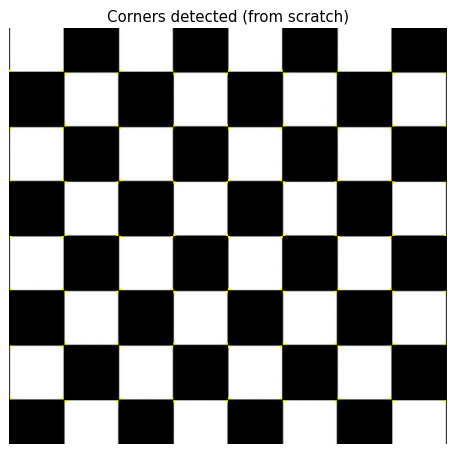

In [2]:
# Harris corner detection, written out step by step.
# The window sum in step 3 is a Gaussian blur: blurring an image IS summing it
# over a weighted window, so cv2.GaussianBlur is the vectorized form of the
# double loop you would otherwise write, and it runs in milliseconds.

gray = cv2.imread('data/chessboard.jpg', cv2.IMREAD_GRAYSCALE)

# Step 1: image gradients
I_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
I_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

# Step 2: products of gradients, per pixel
Ixx = I_x * I_x
Iyy = I_y * I_y
Ixy = I_x * I_y

# Step 3: sum each product over a Gaussian window -> the entries of M
window = (5, 5)
Sxx = cv2.GaussianBlur(Ixx, window, sigmaX=1.5)
Syy = cv2.GaussianBlur(Iyy, window, sigmaX=1.5)
Sxy = cv2.GaussianBlur(Ixy, window, sigmaX=1.5)

# Step 4: corner response R = det(M) - k * trace(M)^2
k = 0.04
det = Sxx * Syy - Sxy ** 2
trace = Sxx + Syy
R = det - k * trace ** 2

# Step 5a: threshold, relative to the strongest response in this image
mask = R > 0.01 * R.max()

# Step 5b: non-maximum suppression. Keep a pixel only if it is the largest
# response in its 5x5 neighborhood, otherwise one corner returns a blob.
local_max = cv2.dilate(R, np.ones((5, 5), np.uint8))
mask &= (R == local_max)

print(f"pixels over threshold: {(R > 0.01 * R.max()).sum()}")
print(f"after non-maximum suppression: {mask.sum()}")

corner_image = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
corner_image[cv2.dilate(mask.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0] = (0, 255, 255)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.title('Corners detected (from scratch)')
plt.axis('off')
plt.show()

#### Using OpenCV's implementation

`cv2.cornerHarris()` does all of the above in one call.

### Parameters

1. **`src`**: single-channel source image. It accepts `uint8` (what `cv2.imread(..., 0)` gives you) as well as `float32`; you do not have to convert.

2. **`blockSize`**: the size of the neighborhood summed to form `M`. Values like 2, 3 or 5 are typical. Bigger means smoother, fewer, more stable corners.

3. **`ksize`**: aperture of the Sobel derivative used for the gradients. Typically 3 or 5. It must be odd and at most 31.

4. **`k`**: the free parameter in $R = \det(M) - k\,\operatorname{trace}(M)^2$. Between 0.04 and 0.06. Larger `k` penalises edges more, so fewer things count as corners.

### Return value

**`dst`**: a `float32` image the same size as the input, holding the response $R$ at every pixel. It is **not** a corner mask: you still have to threshold it, and the threshold is normally set relative to `dst.max()` rather than to an absolute number, because the scale of $R$ depends on the image contrast.

`cornerHarris` does not do non-maximum suppression. If you need one point per corner rather than a blob, use `cv2.goodFeaturesToTrack`, which wraps the same score with suppression and a minimum-distance constraint.

dst dtype: float32  range: -0.031217681 to 0.06471369


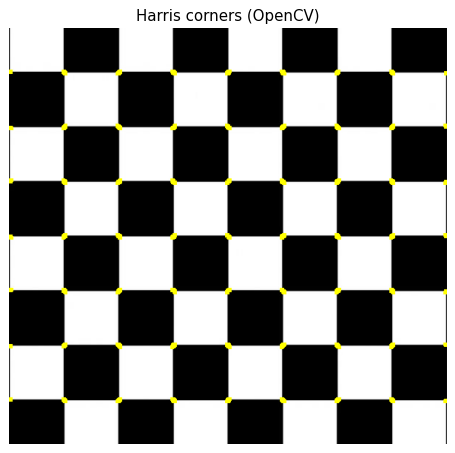

In [3]:
img = cv2.imread('data/chessboard.jpg', 0)
color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# cornerHarris accepts uint8 directly; it returns a float32 response map.
dst = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)
print("dst dtype:", dst.dtype, " range:", dst.min(), "to", dst.max())

# Mark every pixel above the threshold. Do this with a boolean mask, not a
# per-pixel Python loop: a loop with slices like color_img[y-3:y+3] also has a
# bug, because a negative start index wraps round to the far side of the array
# and paints in the wrong place near the border.
mask = dst > 0.01 * dst.max()
mask = cv2.dilate(mask.astype(np.uint8), np.ones((5, 5), np.uint8)) > 0
color_img[mask] = (0, 255, 255)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title('Harris corners (OpenCV)')
plt.axis('off')
plt.show()

Let's see how corner detection works on the `church.jpg` image that we used before for edge detection.

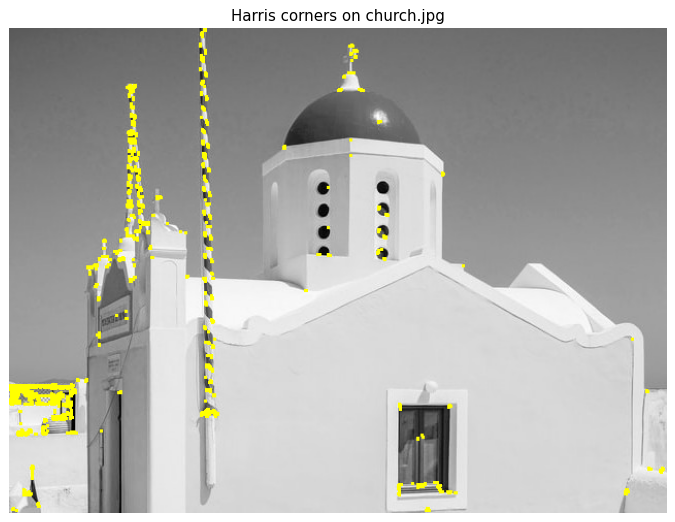

In [4]:
img = cv2.imread('data/church.jpg', 0)
color_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

dst = cv2.cornerHarris(img, blockSize=2, ksize=3, k=0.04)

mask = dst > 0.01 * dst.max()
mask = cv2.dilate(mask.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0
color_img[mask] = (0, 255, 255)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
plt.title('Harris corners on church.jpg')
plt.axis('off')
plt.show()

### Harris is not scale invariant

This is the claim from the lecture, and it is worth measuring rather than believing.

**Repeatability** is the property that matters: run the detector on two images of the same scene and it should fire on the same physical points. Here the two images are the same photograph at different sizes, which is the easiest possible version of the test, since nothing else has changed.

Detect corners at 1x, detect them again at each other scale, map the results back into the original coordinate frame, and count how many of the 1x corners were found again within a few pixels. A scale-invariant detector would score close to 100% everywhere.

Two images are used, and the difference between them is the point.

In [5]:
def harris_points(image, block_size=2, ksize=3, k=0.04, rel_thresh=0.01):
    """Harris corners as (row, col) coordinates, after non-maximum suppression."""
    dst = cv2.cornerHarris(image, block_size, ksize, k)
    keep = dst > rel_thresh * dst.max()
    keep &= (dst == cv2.dilate(dst, np.ones((5, 5), np.uint8)))
    return np.argwhere(keep).astype(float)

def repeatability(image, scales=(0.25, 0.5, 1.0, 2.0)):
    """How many of the corners found at 1x are found again at each other scale."""
    base = harris_points(image)
    rows = []
    for s in scales:
        scaled = cv2.resize(image, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
        pts = harris_points(scaled) / s        # map back to original coordinates
        # generous tolerance: 3 pixels at 1x, scaled up for the shrunken copies
        tol = max(3.0, 3.0 / s)
        d = np.linalg.norm(base[:, None, :] - pts[None, :, :], axis=2)
        rows.append((s, len(pts), (d.min(axis=1) <= tol).mean()))
    return len(base), rows

for name in ('church.jpg', 'chessboard.jpg'):
    image = cv2.imread('data/' + name, 0)
    n_base, rows = repeatability(image)
    print(f"{name}  {image.shape}  {n_base} corners at 1x")
    for s, n, rep in rows:
        print(f"   scale {s:>4}: {n:>4} corners found, "
              f"{rep * 100:5.1f}% of the 1x corners recovered")
    print()

church.jpg  (471, 638)  272 corners at 1x
   scale 0.25:   56 corners found,  58.8% of the 1x corners recovered
   scale  0.5:  137 corners found,  70.6% of the 1x corners recovered
   scale  1.0:  272 corners found, 100.0% of the 1x corners recovered
   scale  2.0:  586 corners found,  96.0% of the 1x corners recovered

chessboard.jpg  (570, 600)  112 corners at 1x
   scale 0.25:   65 corners found, 100.0% of the 1x corners recovered
   scale  0.5:   73 corners found,  96.4% of the 1x corners recovered
   scale  1.0:  112 corners found, 100.0% of the 1x corners recovered
   scale  2.0:  112 corners found, 100.0% of the 1x corners recovered



On `church.jpg` repeatability falls to about 71% at half size and about 59% at quarter size, even with a deliberately generous matching tolerance. Those are the corners that a matching stage would simply never see, and no descriptor can recover them.

On `chessboard.jpg` it stays at essentially 100%. That is not Harris doing better; it is the test image being degenerate. A chessboard has structure at exactly one scale, and its corners are sharp enough to survive resampling, so there is nothing for a scale change to break. Real photographs have structure at every scale, which is why `church.jpg` is the honest test and why a detector that picks its own scale is worth the extra work.

Notice also that the number of corners at 2x is roughly four times the number at 1x. The detector is not finding the same scene in more detail; it is finding a different set of things, because a fixed window covers a quarter as much of the world.

## Blob detection with the Laplacian of Gaussian (LoG)

A *blob* is a region that differs from its surroundings and has a characteristic size. Corners have a position but no size; blobs have both, and that extra number is what buys scale invariance.

The Laplacian of Gaussian kernel is

$$ \nabla^2 g(x, y) = -\frac{1}{\pi \sigma^4} \left[1 - \frac{x^2 + y^2}{2 \sigma^2} \right] e^{-\frac{x^2 + y^2}{2 \sigma^2}} $$

a negative well with a positive rim, often called a Mexican hat. It is circularly symmetric, so unlike a derivative filter it has no preferred direction. Convolving with it gives a large response where the image has a dark spot of roughly the same size as the well.

#### Multiscale blob detection

1. Build LoG kernels for a range of $\sigma$.
2. Convolve the image with each one.
3. Find points that are local maxima in position **and** in $\sigma$.
4. Threshold to drop weak responses.

The $\sigma$ at which a point peaks is its **characteristic scale**, and the detected blob radius is about $\sqrt{2}\,\sigma$.

One detail that the formula hides: the raw response shrinks as $\sigma$ grows, simply because the kernel spreads its weight over more pixels. It has to be multiplied by $\sigma^2$ before peaks at different scales can be compared. Without that normalization the maximum is always at the smallest $\sigma$ you tried. `skimage.feature.blob_log` does this for you.

208 blobs
radii: 4.2 to 28.3 pixels


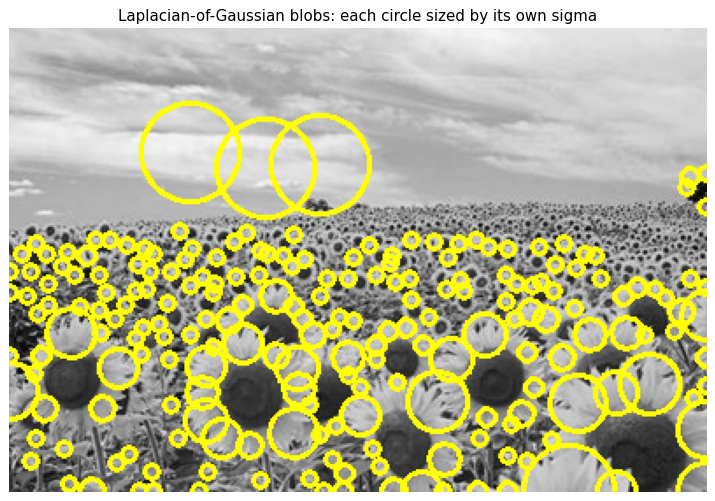

In [6]:
from skimage.feature import blob_log

img = cv2.imread('data/sunflowers.jpg', 0)

# blob_log builds the LoG scale space for us, including the sigma^2
# normalization without which the peak is always at the smallest sigma.
blobs = blob_log(img, min_sigma=3, max_sigma=20, num_sigma=15, threshold=0.10)

# blob_log reports sigma; the radius of the blob it found is about sqrt(2)*sigma
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)

print(f"{len(blobs)} blobs")
print(f"radii: {blobs[:, 2].min():.1f} to {blobs[:, 2].max():.1f} pixels")

out = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for y, x, r in blobs:
    cv2.circle(out, (int(x), int(y)), int(r), (0, 255, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title('Laplacian-of-Gaussian blobs: each circle sized by its own sigma')
plt.axis('off')
plt.show()

#### A different tool: `cv2.SimpleBlobDetector`

OpenCV ships a blob detector, and it is worth being clear that **it does not implement the algorithm above**. `SimpleBlobDetector` works like this:

1. Binarize the image at a sequence of thresholds (by default from `minThreshold=50` to `maxThreshold=220` in steps of `thresholdStep=10`).
2. Extract connected components from each binary image.
3. Group components across thresholds whose centers are close together.
4. Keep a group if it passes the enabled filters, and report its center and size.

No Gaussian, no Laplacian, no scale space. It is a connected-components counter, and for something like counting coins on a plain background that is exactly the right tool. It is just not LoG.

**The trap:** several filters are on by default and quietly reject blobs you meant to keep. Setting only `filterByArea` leaves these active:

| Parameter | Default | Effect |
|---|---|---|
| `filterByColor` | `True`, `blobColor=0` | keeps **dark** blobs only |
| `filterByArea` | `True`, `minArea=25` | |
| `filterByCircularity` | `False` | |
| `filterByInertia` | `True`, `minInertiaRatio=0.1` | rejects very elongated blobs |
| `filterByConvexity` | `True`, `minConvexity=0.95` | rejects blobs with concave outlines |

Set every filter you care about explicitly, including the ones you want turned off.

196 blobs with the filters set explicitly


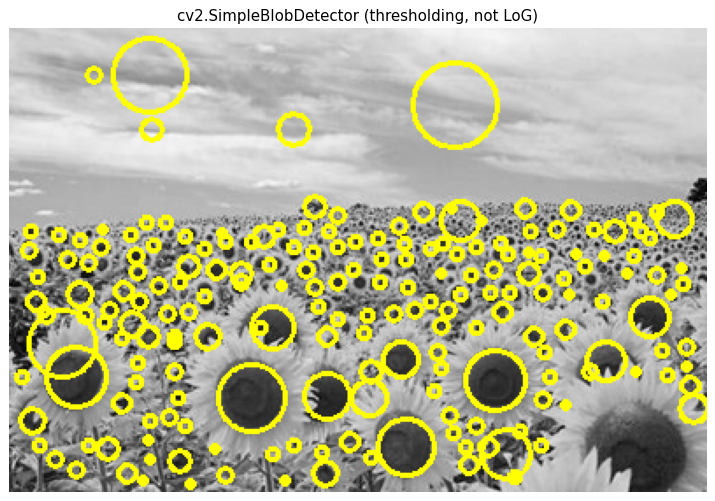

In [7]:
img = cv2.imread('data/sunflowers.jpg', 0)

params = cv2.SimpleBlobDetector_Params()

# Set every filter explicitly, including the ones being switched off, so that
# nothing is rejected by a default you did not choose.
params.filterByColor = True
params.blobColor = 0            # 0 = dark blobs, 255 = light blobs
params.filterByArea = True
params.minArea = 20
params.maxArea = 10000
params.filterByCircularity = False
params.filterByInertia = False
params.filterByConvexity = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(img)
print(f"{len(keypoints)} blobs with the filters set explicitly")

out = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for kp in keypoints:
    x, y = map(int, kp.pt)
    cv2.circle(out, (x, y), int(kp.size / 2), (0, 255, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title('cv2.SimpleBlobDetector (thresholding, not LoG)')
plt.axis('off')
plt.show()

#### Toy example: detecting and counting coins

`blobColor=0` means the detector looks for **dark** blobs. The coins in `coins.png` are light on a dark background, so the image is inverted first to make them dark. (The comment in the original version of this cell had this backwards.)

Small coins:  10
Medium coins: 3
Large coins:  2


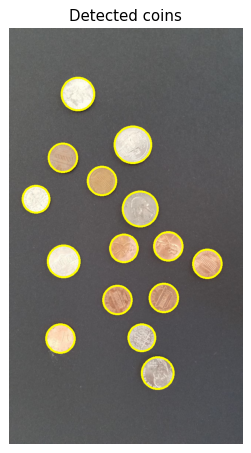

In [8]:
img = cv2.imread("data/coins.png", cv2.IMREAD_COLOR)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# The coins are light on a dark background. blobColor=0 looks for DARK blobs,
# so invert the image to turn the coins into dark blobs on a light background.
gray_img = cv2.bitwise_not(gray_img)
blurred = cv2.GaussianBlur(gray_img, (7, 7), 0)

params = cv2.SimpleBlobDetector_Params()
params.filterByColor = True
params.blobColor = 0
params.filterByArea = True
params.minArea = 3000
params.maxArea = 7000
params.filterByCircularity = False
params.filterByInertia = False
params.filterByConvexity = False

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(blurred)

small  = [k for k in keypoints if k.size < 75]
medium = [k for k in keypoints if 75 <= k.size < 85]
large  = [k for k in keypoints if k.size >= 85]
print(f"Small coins:  {len(small)}")
print(f"Medium coins: {len(medium)}")
print(f"Large coins:  {len(large)}")

out_img = img.copy()
for k in keypoints:
    x, y = map(int, k.pt)
    cv2.circle(out_img, (x, y), int(k.size // 2), (0, 255, 255), 3)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
plt.title("Detected coins")
plt.axis("off")
plt.show()

## Histograms in Image Processing

A histogram counts how many pixels have each intensity value: the x-axis is the value, the y-axis is the number of pixels with it. For an 8-bit image there are 256 possible values, so the histogram has 256 entries indexed `0` through `255`.

#### Types

1. **Grayscale histograms**: the distribution of intensities in a single-channel image.
2. **Color histograms**: one histogram per channel, concatenated. For 8-bit RGB that is 3 x 256 = 768 numbers, whatever the resolution of the image.
3. **Gradient histograms**: the distribution of gradient *orientations* rather than intensities. HOG and SIFT are both built from these.

#### The limitation that motivates everything after this

A histogram records values and discards positions completely. Different images can have identical histograms, and no image can be reconstructed from one. That is fine for asking "are these two pictures of a similar scene" and useless for asking "which part of this picture matches which part of that one".

---

### Intensity histogram (grayscale)

A note on the bin edges, because this is a common and quiet bug. For 256 bins over 8-bit data the range must be `(0, 256)`, not `(0, 255)`. With `(0, 255)` each bin is 255/256 of a level wide, so the bins drift out of alignment with the integer values. `cv2.calcHist` takes `[0, 256]` for the same reason.

matches cv2.calcHist: True
bin widths are exactly 1: True


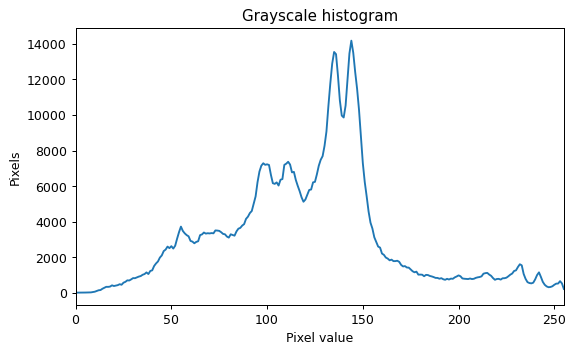

Feature vector length: 256   total pixels: 786432


In [9]:
image = cv2.imread('data/tennis_court2.jpg', cv2.IMREAD_GRAYSCALE)

# 256 bins over 8-bit data: the range is (0, 256), not (0, 255).
histogram, bin_edges = np.histogram(image, bins=256, range=(0, 256))

# cv2.calcHist gives the identical answer, and is faster on large images.
cv_hist = cv2.calcHist([image], [0], None, [256], [0, 256]).ravel()
print("matches cv2.calcHist:", np.array_equal(histogram, cv_hist.astype(int)))
print("bin widths are exactly 1:", np.allclose(np.diff(bin_edges), 1.0))

plt.figure(figsize=(7, 4))
plt.title("Grayscale histogram")
plt.xlabel("Pixel value")
plt.ylabel("Pixels")
plt.xlim(0, 255)
plt.plot(histogram)
plt.show()

print("Feature vector length:", histogram.shape[0], "  total pixels:", histogram.sum())

### Color histogram (RGB image)

Remember that `cv2.imread` returns **BGR**, so `cv2.split` gives you blue first. Plotting the three arrays as if they were RGB swaps two of the curves, and the result looks completely plausible while being wrong.

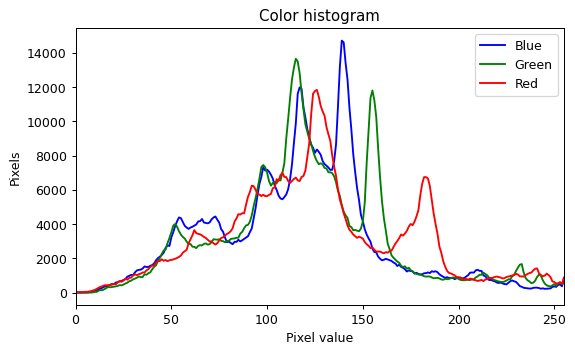

Color histogram descriptor length: 768 = 3 x 256


In [10]:
image = cv2.imread('data/tennis_court2.jpg')

# cv2.imread returns BGR, so channel 0 is blue.
channels = ('b', 'g', 'r')
names = ('Blue', 'Green', 'Red')

plt.figure(figsize=(7, 4))
plt.title("Color histogram")
plt.xlabel("Pixel value")
plt.ylabel("Pixels")

descriptor = []
for i, (color, name) in enumerate(zip(channels, names)):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256]).ravel()
    descriptor.append(hist)
    plt.plot(hist, color=color, label=name)

plt.xlim(0, 255)
plt.legend()
plt.show()

descriptor = np.concatenate(descriptor)
print("Color histogram descriptor length:", descriptor.shape[0], "= 3 x 256")

## Histogram of Oriented Gradients (HOG)

HOG describes an object's local shape by the distribution of gradient directions in small patches of the image. Introduced by Dalal and Triggs in 2005 for pedestrian detection.

The steps:

1. **Gradient computation.** Compute $g_x$ and $g_y$, usually with the simplest possible kernel, $[-1, 0, 1]$ and its transpose. From these get the magnitude $\sqrt{g_x^2 + g_y^2}$ and the orientation $\arctan(g_y / g_x)$.

2. **Orientation binning.** Divide the image into **cells** (classically 8x8 pixels). In each cell build a histogram of gradient orientation, with each pixel contributing its *magnitude* rather than a count of one. That weighting is what stops faint noise gradients from counting as much as real edges.

   The histogram has 9 bins covering 0 to 180 degrees, not 0 to 360. HOG uses *unsigned* gradients, so an edge and the same edge with light and dark swapped land in the same bin. A pedestrian detector should not care whether someone is wearing a light shirt against a dark wall or the reverse.

3. **Block normalization.** Group cells into **blocks** (classically 2x2 cells) and normalize each block's concatenated histogram by its own magnitude. This removes the effect of local contrast. Blocks **overlap**, sliding one cell at a time, so most cells appear in several blocks normalized differently. The redundancy is deliberate.

4. **Descriptor.** Concatenate every block's normalized histogram into one vector.

#### HOG from scratch: one cell

The cell below computes the histogram for a single 8x8 cell, which is step 2 for one cell only. It is not a HOG descriptor: there is no grid of cells and no block normalization. It is here so you can see exactly what one of those 9-number histograms contains.

One 8x8 cell, rows 60-67 and columns 28-35
bin centers (degrees): [' 10', ' 30', ' 50', ' 70', ' 90', '110', '130', '150', '170']
histogram          : [ 947.4  535.1   36.2  106.7  381.8  172.7  292.   844.9 1288.3]
dominant direction : 170 degrees


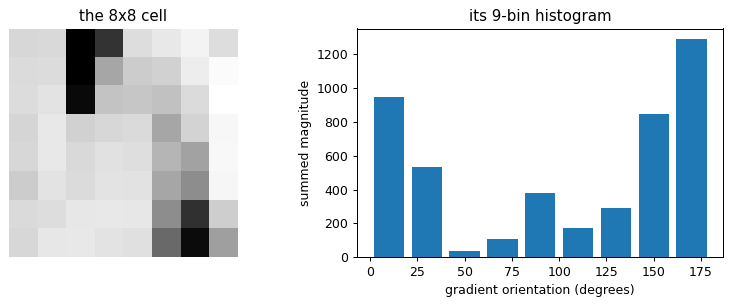

In [11]:
image = cv2.imread('data/texture_features.jpg', 0)
image = cv2.resize(image, (64, 128))       # cv2.resize takes (width, height)

gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=1)   # ksize=1 gives [-1, 0, 1]
gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=1)

magnitude = np.sqrt(gx ** 2 + gy ** 2)
# %180 folds the direction onto 0..180: HOG uses UNSIGNED gradients, so an
# edge and the same edge with light and dark swapped share a bin.
orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

def cell_histogram(mag, ang, num_bins=9):
    """The 9-bin orientation histogram of one cell, weighted by magnitude."""
    bin_width = 180 / num_bins
    hist = np.zeros(num_bins)
    idx = np.minimum((ang / bin_width).astype(int), num_bins - 1)
    for b in range(num_bins):
        hist[b] = mag[idx == b].sum()
    return hist

# One 8x8 cell, taken from the middle of the image.
r0, c0 = 60, 28
hist = cell_histogram(magnitude[r0:r0 + 8, c0:c0 + 8],
                      orientation[r0:r0 + 8, c0:c0 + 8])

print("One 8x8 cell, rows 60-67 and columns 28-35")
print("bin centers (degrees):", [f"{10 + 20 * b:3d}" for b in range(9)])
print("histogram          :", np.round(hist, 1))
print("dominant direction :", f"{10 + 20 * int(hist.argmax())} degrees")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].imshow(image[r0:r0 + 8, c0:c0 + 8], cmap='gray')
ax[0].set_title('the 8x8 cell'); ax[0].axis('off')
ax[1].bar(np.arange(9) * 20 + 10, hist, width=16)
ax[1].set_xlabel('gradient orientation (degrees)')
ax[1].set_ylabel('summed magnitude')
ax[1].set_title('its 9-bin histogram')
plt.tight_layout()
plt.show()

#### HOG with OpenCV

`cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)` takes all its sizes in **pixels**, and all of them as `(width, height)`.

With the classic pedestrian settings the descriptor length is fixed by the geometry, and it is worth computing it by hand once so the number is not a surprise.

In [12]:
image = cv2.imread('data/texture_features.jpg', 0)
image = cv2.resize(image, (64, 128))

win_size, block_size, block_stride, cell_size, nbins = (64, 128), (16, 16), (8, 8), (8, 8), 9
hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, nbins)
descriptor = hog.compute(image)

# Work the length out by hand so the number is not a mystery.
bx = (win_size[0] - block_size[0]) // block_stride[0] + 1
by = (win_size[1] - block_size[1]) // block_stride[1] + 1
cells_per_block = (block_size[0] // cell_size[0]) * (block_size[1] // cell_size[1])

print(f"blocks across the window : {bx} x {by} = {bx * by}")
print(f"cells per block          : {cells_per_block}")
print(f"bins per cell            : {nbins}")
print(f"descriptor length        : {bx} x {by} x {cells_per_block} x {nbins} = "
      f"{bx * by * cells_per_block * nbins}")
print(f"hog.compute() returned   : {descriptor.shape[0]}")
print()
print("The lecture's small worked example gives 36 per block x 9 blocks = 324.")
print("That is a smaller window, not a different formula.")

blocks across the window : 7 x 15 = 105
cells per block          : 4
bins per cell            : 9
descriptor length        : 7 x 15 x 4 x 9 = 3780
hog.compute() returned   : 3780

The lecture's small worked example gives 36 per block x 9 blocks = 324.
That is a smaller window, not a different formula.


### Applications of HoG: pedestrian detection

The classic use of HOG, and the one it was invented for: find people in an image so a car can warn the driver or brake.

The method is a **sliding window**. Slide a 64x128 pixel window over the image at many positions and many scales, compute the 3,780-number HOG descriptor for each window, and ask a linear SVM whether it contains a person. OpenCV ships the SVM weights that Dalal and Triggs trained, so you can run the whole thing in four lines.

`detectMultiScale` returns the boxes it accepted and, if you ask for them, the SVM's decision values. Those weights are the confidence, and you will want them.

Run it on a real photograph rather than a curated one, and see what actually comes back.

window the SVM was trained on: (64, 128)  descriptor length: 3780



11 raw detections, SVM weights 0.04 to 0.94
4 survive a weight threshold of 0.7


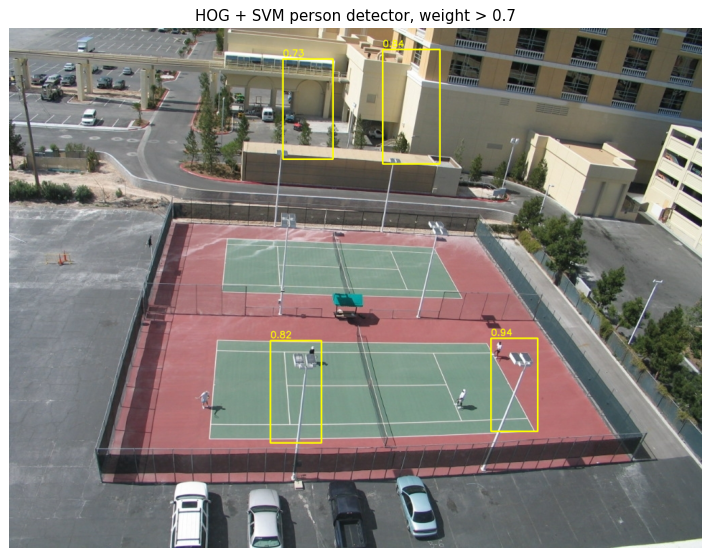

In [13]:
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
print("window the SVM was trained on:", hog.winSize, " descriptor length:", hog.getDescriptorSize())

img = cv2.imread('data/tennis_court2.jpg')
scene = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

boxes, weights = hog.detectMultiScale(scene, winStride=(4, 4), padding=(8, 8), scale=1.05)
weights = weights.ravel()
print(f"\n{len(boxes)} raw detections, SVM weights {weights.min():.2f} to {weights.max():.2f}")

keep = weights > 0.7
print(f"{keep.sum()} survive a weight threshold of 0.7")

out = scene.copy()
for (x, y, w, h), wt in zip(boxes[keep], weights[keep]):
    cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 255), 3)
    cv2.putText(out, f"{wt:.2f}", (x, max(y - 8, 24)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

plt.figure(figsize=(10, 7.5))
plt.imshow(cv2.cvtColor(cv2.resize(out, None, fx=0.5, fy=0.5), cv2.COLOR_BGR2RGB))
plt.title('HOG + SVM person detector, weight > 0.7')
plt.axis('off')
plt.show()

The detector missed every one of the tennis players and fired on poles, light standards and building edges instead. Both halves of that have the same cause, and it is worth understanding because it applies to every sliding-window detector.

**Why the players are missed.** The model was trained on people filling a 64x128 pixel window. `detectMultiScale` handles that by shrinking the image repeatedly and re-running, so a person larger than the window is eventually found. A person *smaller* than 64x128 in the original image can never be found, because the search only ever scales down. The players here are roughly 20 pixels tall.

**Why the poles fire.** At a coarse scale, a vertical structure with a bit of horizontal detail at the top produces a gradient pattern that genuinely resembles a standing person's silhouette. HOG throws away color and absolute intensity by design, and what is left is not enough to tell a light pole from a person.

The fix for the first problem is to give the detector people at a size it can see. Crop around two players and enlarge.

left court: 1 detection(s), weights [0.74]
right court: 1 detection(s), weights [0.85]


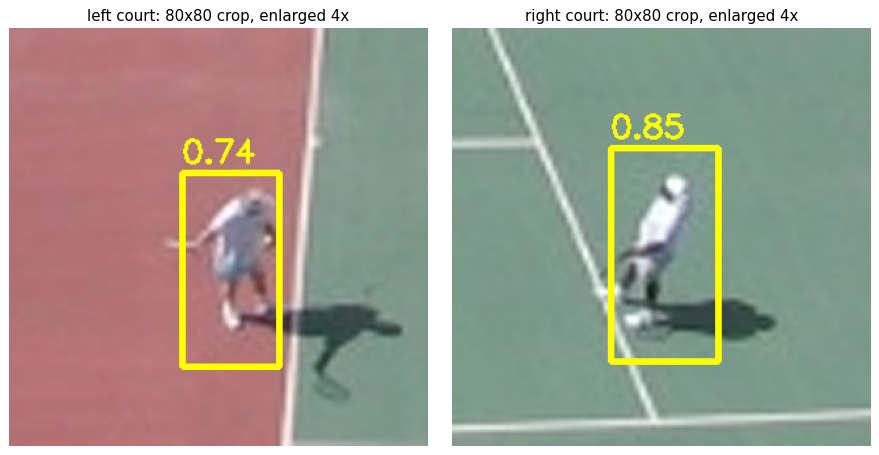

In [14]:
players = {'left court': (285, 545), 'right court': (670, 545)}
fig, axes = plt.subplots(1, len(players), figsize=(10, 5))

for ax, (label, (cx, cy)) in zip(axes, players.items()):
    crop = img[cy - 40:cy + 40, cx - 40:cx + 40]          # 80x80 pixels
    big = cv2.resize(crop, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)

    boxes, weights = hog.detectMultiScale(big, winStride=(4, 4),
                                          padding=(16, 16), scale=1.03)
    out = big.copy()
    for (x, y, w, h), wt in zip(boxes, weights.ravel()):
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 255), 3)
        cv2.putText(out, f"{wt:.2f}", (x, max(y - 8, 24)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    print(f"{label}: {len(boxes)} detection(s), weights {np.round(weights.ravel(), 2)}")
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{label}: 80x80 crop, enlarged 4x")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Scale Invariant Feature Transform (SIFT)

David Lowe, 1999 and 2004. A detector and a descriptor together, and the standard against which everything since has been measured.

#### Steps

1. **Scale-space extrema detection.** Blur the image with Gaussians at a range of $\sigma$ and subtract neighbouring pairs, giving a **difference of Gaussians** (DoG) stack. DoG closely approximates the scale-normalized Laplacian from the blob section and costs far less, because the blurred copies have to be built anyway. Keypoints are local extrema in position and in scale.

2. **Keypoint localization.** Refine each candidate to sub-pixel position and reject two kinds of bad ones: low-contrast points, which are unstable under noise, and points lying along an edge. An edge point sits on a ridge in the response, which falls away steeply across the ridge and hardly at all along it, so from one image to the next the point slides along the edge and is reported somewhere else. SIFT rejects those by comparing how sharply the response bends in its two extreme directions, which is the same diagnosis the Harris test makes.

3. **Orientation assignment.** Build a histogram of gradient orientations over the patch and take its dominant direction. Rotating the patch so that direction always points the same way is what makes the descriptor rotation invariant. A patch with several comparable peaks produces several keypoints at the same location, one per peak.

4. **Descriptor.** Divide the (oriented, scaled) patch into a 4x4 grid, build an 8-bin orientation histogram in each cell, concatenate and normalize: 4 x 4 x 8 = **128** numbers.

5. **Matching.** Nearest neighbor under Euclidean distance, then Lowe's ratio test.

#### A note on availability

SIFT was patented, and for years the advice was to install `opencv-contrib-python` and use `cv2.xfeatures2d.SIFT_create()`. **The patent expired in March 2020** and SIFT moved into the main OpenCV module. Use `cv2.SIFT_create()`. Tutorials telling you otherwise predate the change.

3347 keypoints
descriptors array: (3347, 128)  (one row per keypoint, 128 numbers each)
keypoint sizes: 1.8 to 201.4 pixels (the detector chose these, they were not set)


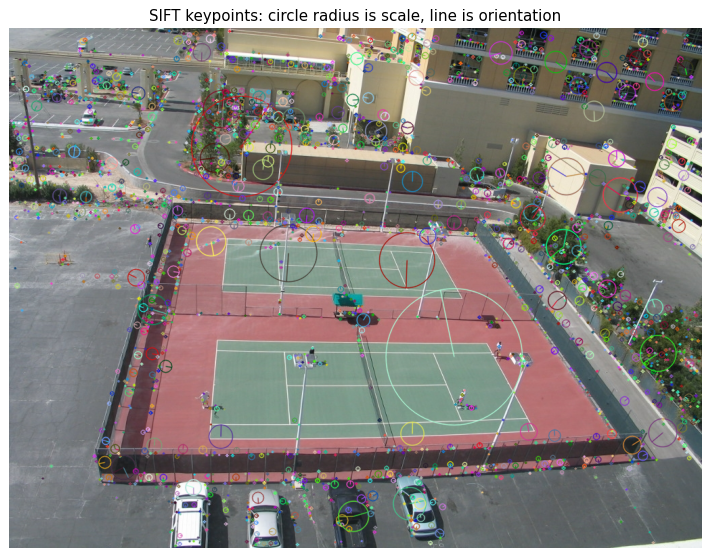

In [15]:
image = cv2.imread('data/tennis_court2.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

print(f"{len(keypoints)} keypoints")
print(f"descriptors array: {descriptors.shape}  (one row per keypoint, 128 numbers each)")
sizes = np.array([kp.size for kp in keypoints])
print(f"keypoint sizes: {sizes.min():.1f} to {sizes.max():.1f} pixels "
      f"(the detector chose these, they were not set)")

# DRAW_RICH_KEYPOINTS draws each keypoint as a circle sized by its scale,
# with a radius line showing the orientation SIFT assigned to it.
out = cv2.drawKeypoints(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), keypoints, None,
                        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(10, 7.5))
plt.imshow(out)
plt.axis('off')
plt.title('SIFT keypoints: circle radius is scale, line is orientation')
plt.show()

### Testing the invariance claims

SIFT is advertised as invariant to scale and rotation and partially invariant to viewpoint. Those are testable claims, so test them.

Three transformed versions of the same photograph:

- a **crop**, which changes translation and field of view but not scale,
- a **half-size copy**, which is an actual scale change,
- a **rotation** by 45 degrees.

For each, match against the original and count how many matches survive Lowe's ratio test. The crop is the easy case; the two that matter are the scaled and rotated ones.

Two details in the matching code worth copying:

- `bf.knnMatch(..., k=2)` asks for the two nearest neighbors, because the ratio test needs the second one.
- Sort the surviving matches by distance before drawing a subset. Taking `good[:100]` without sorting shows you an arbitrary hundred rather than the best hundred, which makes the result look worse than it is.

crop (no scale change)     531 keypoints     564 pass the ratio test     517 agree with one transform   (92%)
half size                 1206 keypoints     951 pass the ratio test     907 agree with one transform   (95%)


rotated 45 degrees        3434 keypoints    1839 pass the ratio test    1785 agree with one transform   (97%)


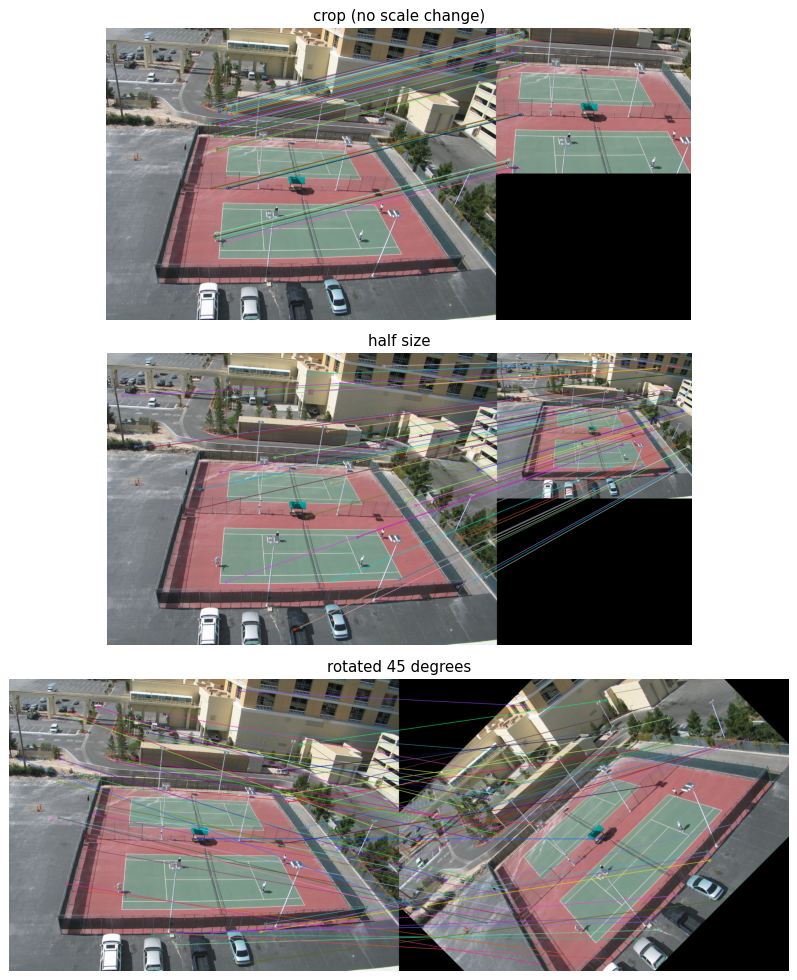

In [16]:
original = cv2.imread('data/tennis_court2.jpg')
gray_original = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
h, w = original.shape[:2]

variants = {}
variants['crop (no scale change)'] = original[int(h * .25):int(h * .75),
                                              int(w * .25):int(w * .75)]
variants['half size']              = cv2.resize(original, None, fx=0.5, fy=0.5,
                                                interpolation=cv2.INTER_AREA)
M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)
variants['rotated 45 degrees']     = cv2.warpAffine(original, M, (w, h))

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_original, None)
bf = cv2.BFMatcher(cv2.NORM_L2)

fig, axes = plt.subplots(len(variants), 1, figsize=(11, 11))

for ax, (label, variant) in zip(axes, variants.items()):
    gray2 = cv2.cvtColor(variant, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # k=2 because Lowe's ratio test needs the second-nearest neighbor too
    good = [m for m, n in bf.knnMatch(des1, des2, k=2)
            if m.distance < 0.75 * n.distance]

    # Geometric consistency check. Every one of these variants is related to the
    # original by a single transform, so fitting one with RANSAC and counting the
    # matches that agree with it tells us how many of the matches are really right.
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, ransacReprojThreshold=3.0)
    inliers = [m for m, keep in zip(good, mask.ravel()) if keep]

    print(f"{label:24} {len(kp2):>5} keypoints"
          f"   {len(good):>5} pass the ratio test"
          f"   {len(inliers):>5} agree with one transform"
          f"   ({100 * len(inliers) / len(good):.0f}%)")

    # Sort before taking a subset, so we draw the BEST 60 and not an arbitrary 60
    inliers.sort(key=lambda m: m.distance)
    drawn = cv2.drawMatches(original, kp1, variant, kp2, inliers[:60], None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

Read the counts rather than the pictures.

Around 95% of the matches that pass the ratio test also agree with a single transform between the two images. That second number is the honest one: the ratio test is a local decision made one feature at a time, and the RANSAC fit is a global check that asks whether all of them tell the same story. A match can pass the ratio test and still be wrong, and the gap between the two columns is how many.

The **half size** copy and the **45 degree rotation** both keep around a thousand geometrically consistent matches. Neither transformation is something raw pixel values survive: halve the image and every value is a different average of different neighbors; rotate it and no pixel is where it was. The descriptors survive because the patch size came from the characteristic scale and the patch orientation came from the dominant gradient.

The **crop** yields fewer matches than either, which looks backwards until you notice that the crop threw away three quarters of the image. Fewer matches because there is less overlap, not because cropping is harder.

Two things worth knowing about the drawing. The lines fan across the whole width because the two images are drawn side by side, so a short displacement in the scene still becomes a long line on the page; crossing lines are not by themselves evidence of bad matches. And `knnMatch(des1, des2)` searches in one direction only, so several descriptors in the first image can pick the same partner in the second. If you need a one-to-one correspondence, match both ways and keep the pairs that agree, or use `cv2.BFMatcher(norm, crossCheck=True)`, which does that but cannot be combined with `knnMatch`.

### ORB: the one that actually runs on a robot

SIFT is accurate and slow. ORB (Rublee et al., 2011) was designed as a free, fast replacement:

- **Detector**: FAST corners, plus a measure to keep the strongest, plus an orientation from the patch's intensity centroid.
- **Descriptor**: BRIEF, a **binary** string built from a fixed pattern of pixel-pair comparisons, steered by the keypoint orientation.

The descriptor is the interesting part. SIFT compares 128 floating-point numbers with Euclidean distance. ORB compares 256 bits with **Hamming distance**, which on modern hardware is a handful of XOR and popcount instructions. That is why ORB-SLAM and most robotics stacks run ORB: it fits inside a frame budget that SIFT does not.

The matcher has to change with it. `cv2.NORM_HAMMING` for ORB, `cv2.NORM_L2` for SIFT. Using the wrong norm gives you nonsense rather than an error.

In [17]:
import time

original = cv2.imread('data/tennis_court2.jpg')
gray1 = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
rotated = cv2.warpAffine(original, cv2.getRotationMatrix2D(
    (original.shape[1] / 2, original.shape[0] / 2), 45, 1.0),
    (original.shape[1], original.shape[0]))
gray2 = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

detectors = {
    'SIFT': (cv2.SIFT_create(),              cv2.NORM_L2),
    'ORB':  (cv2.ORB_create(nfeatures=5000), cv2.NORM_HAMMING),
}

for name, (det, norm) in detectors.items():
    t0 = time.perf_counter()
    k1, d1 = det.detectAndCompute(gray1, None)
    k2, d2 = det.detectAndCompute(gray2, None)
    t_detect = time.perf_counter() - t0

    bf = cv2.BFMatcher(norm)
    t0 = time.perf_counter()
    good = [m for m, n in bf.knnMatch(d1, d2, k=2) if m.distance < 0.75 * n.distance]
    t_match = time.perf_counter() - t0

    print(f"{name:5}  descriptor {str(d1.shape[1]):>3} x {d1.dtype}"
          f"   {len(k1):>5} keypoints"
          f"   detect {t_detect * 1000:6.0f} ms"
          f"   match {t_match * 1000:6.0f} ms"
          f"   {len(good):>5} good matches")

print()
print("ORB stores 32 bytes per keypoint against SIFT's 128 float32 values (512 bytes),")
print("and compares them with Hamming distance instead of Euclidean.")

SIFT   descriptor 128 x float32    3347 keypoints   detect    282 ms   match     36 ms    1839 good matches
ORB    descriptor  32 x uint8    5000 keypoints   detect     36 ms   match     45 ms    2686 good matches

ORB stores 32 bytes per keypoint against SIFT's 128 float32 values (512 bytes),
and compares them with Hamming distance instead of Euclidean.
